In [ ]:
from pathlib import Path

from lassi.profiler import Timer, MultiProfiler, GPUProfiler, CPUProfiler
from lassi.source_file import SourceFile
from lassi.executer import FunctionalValidator
from typing import Annotated

from openai import AsyncOpenAI
from groq import Groq

from lassi.compiler import Compiler, CompilerTool, CompilationError

from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

import subprocess

## Minimal C Example

In [3]:
# Declare a new file

source_file = SourceFile(
    file_name = Path("test.c")
)

source_file

Source File:
   file name: test.c,
   folder path: .,
   language:    Language.C,
   executable:  None

In [4]:
source_file.write( # this could be the LLM output
    """#include <stdio.h>

        int main(void) {
            printf("Compiler test successful!");
            return 0;
        }
    """
)

executable = source_file.compile()
success = source_file.execute()
report = source_file.get_last_execution_report()

Compiling /home/gbrun/LASSI-TOOLS/test.c using gcc...
Compiling with command: gcc /home/gbrun/LASSI-TOOLS/test.c -o /home/gbrun/LASSI-TOOLS/test
Running with command: /home/gbrun/LASSI-TOOLS/test


In [6]:
executable

In [ ]:
report # default report is latency

## More complex CUDA example

In [ ]:
source_file = SourceFile(
    file_name = Path("similarity_cuda_test.cu"),
    folder_path = Path("/home/gbrun/test_cuda_folder/src/") # <-- from another folder
)

In [ ]:
source_file # this time lang is CUDA

In [ ]:
source_file.compile(
    kwds="-O3", # all flags go here
    output_file=Path("test_cuda") # custom name
    ) 

In [ ]:
source_file.execute(
    args="100 100", # need args
    profiler=MultiProfiler([Timer(),CPUProfiler(),GPUProfiler()]) # GPU profiler. There is NVIDIA and AMD
    )

In [ ]:
source_file.get_last_execution_report() # more complex report

## Code Generation

In [ ]:
import dotenv
from dataclasses import dataclass
from pydantic import BaseModel, Field
from pydantic_ai import Agent
from pydantic_ai.models.groq import GroqModel

from openai import AsyncOpenAI

In [ ]:
dotenv.load_dotenv()

In [ ]:
source_file = SourceFile(
    file_name = Path("llm_generated_code.c"),
)

In [ ]:
@dataclass
class CodeGenDependencies:
    language: Annotated[str, Field(description="Language to implement the code in.")]

@dataclass
class CodeGenOutput:
    code: Annotated[str, Field(description="Valid code that follows the requested task. Code only.")]

In [ ]:
MODEL_NAME = "openai/gpt-oss-120b"

### Groq model

In [ ]:
model = GroqModel(MODEL_NAME)

### Locally hosted OpenAI (vLLM)

In [ ]:
# model = OpenAIChatModel(MODEL_NAME, provider=OpenAIProvider(base_url="http://localhost:8000/v1"))

### Declare Agent

In [ ]:
agent = Agent(
    model=model,
    instructions=(
        "You are a helpful coding tool."
    ),
    output_type= CodeGenOutput,
)

### Create and test a new file

In [ ]:
deps = CodeGenDependencies(language=source_file.lang.value)

result = await agent.run("Write me a C program that takes from args a number N and prints the first N args of the fibonacci sequence.")

source_file.write(result.output.code)

In [ ]:
print(source_file.read())

In [ ]:
source_file.compile()

unit_test = [
    FunctionalValidator(
        args = "4",
        golden_output="0 1 1 2\n",
        ret_code=0),
    FunctionalValidator(
        args = "1",
        golden_output="0\n",
        ret_code=0),
    FunctionalValidator(
        args = "5",
        golden_output="0 1 1 2 3\n",
        ret_code=0),
]

output = source_file.execute(
    validator = unit_test,
)

source_file.get_execution_history()

In [ ]:
source_file.compile()

output = source_file.execute(
    args = "10000000",
    profiler=CPUProfiler()
)

source_file.get_execution_history()

In [ ]:
cpuprof = CPUProfiler()
cpuprof.start()

In [ ]:
cpuprof.stop()

In [ ]:
list(cpuprof._probe.powers)

In [ ]:
output

In [ ]:
source_file

## PolyBench

In [2]:
class CustomCompilerTool(CompilerTool):
    def compile(
        self,
        file: Path = None,
        output_file : Path = None,
        kwds: str = None,
    ) -> Path:

        # Build command
        cmd = [
            "gcc",
            "-O3",
            "-I", "/home/gbrun/PolyBenchC-4.2.1/utilities",
            "-I", "/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm",
            "/home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c",
            str(file),
            "-DPOLYBENCH_TIME",
            "-DEXTRALARGE_DATASET",
            "-o", str(output_file),
        ]

        print(f"Compiling with command: {' '.join(cmd)}")

        # Run compiler
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            raise CompilationError(f"Compilation failed:\n{result.stderr}")

        return output_file

In [3]:
class CustomCompilerToolO0(CompilerTool):
    def compile(
        self,
        file: Path = None,
        output_file : Path = None,
        kwds: str = None,
    ) -> Path:

        # Build command
        cmd = [
            "gcc",
            "-O0",
            "-I", "/home/gbrun/PolyBenchC-4.2.1/utilities",
            "-I", "/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm",
            "/home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c",
            str(file),
            "-DPOLYBENCH_TIME",
            "-DEXTRALARGE_DATASET",
            "-o", str(output_file),
        ]

        print(f"Compiling with command: {' '.join(cmd)}")

        # Run compiler
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            raise CompilationError(f"Compilation failed:\n{result.stderr}")

        return output_file

In [8]:

source_file_og = SourceFile(
    file_name = Path("3mm.c"),
    folder_path=Path("/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/"),
    compiler_tool=CustomCompilerToolO0(
        compiler=Compiler.GCC),
)
source_file_og.compile(
    output_file = Path("/home/gbrun/PolyBenchC-4.2.1/my_bench")
)

source_file_og.execute(profiler=MultiProfiler([Timer(), CPUProfiler()]))

source_file_og.get_last_execution_report()

Compiling with command: gcc -O0 -I /home/gbrun/PolyBenchC-4.2.1/utilities -I /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm /home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/3mm.c -DPOLYBENCH_TIME -DEXTRALARGE_DATASET -o /home/gbrun/PolyBenchC-4.2.1/my_bench
Running with command: /home/gbrun/PolyBenchC-4.2.1/my_bench


[TimerReport(latency=257.1049673468806),
 CPUReport(average_power=27.370520606531883, power_peak=30.272, energy=7037.117259037256, memory_usage_avg=0.0, memory_usage_peak=0.0, utilization_avg=0.0, utilization_peak=0.0)]

In [9]:
source_file_og_o3 = SourceFile(
    file_name = Path("3mm.c"),
    folder_path=Path("/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/"),
    compiler_tool=CustomCompilerTool(
        compiler=Compiler.GCC),
)
source_file_og_o3.compile(
    output_file = Path("/home/gbrun/PolyBenchC-4.2.1/my_bench")
)

source_file_og_o3.execute(profiler=MultiProfiler([Timer(), CPUProfiler()]))

source_file_og_o3.get_last_execution_report()

Compiling with command: gcc -O3 -I /home/gbrun/PolyBenchC-4.2.1/utilities -I /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm /home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/3mm.c -DPOLYBENCH_TIME -DEXTRALARGE_DATASET -o /home/gbrun/PolyBenchC-4.2.1/my_bench
Running with command: /home/gbrun/PolyBenchC-4.2.1/my_bench


[TimerReport(latency=69.67606881726533),
 CPUReport(average_power=28.41410903873745, power_peak=28.97, energy=1979.7788692746162, memory_usage_avg=0.0, memory_usage_peak=0.0, utilization_avg=0.0, utilization_peak=0.0)]

In [5]:
source_file_v1 = source_file_v1 = SourceFile(
    file_name = Path("3mm_v1.c"),
    folder_path=Path("/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/"),
    compiler_tool=CustomCompilerTool(
        compiler=Compiler.GCC),
)

source_file_v1.compile(
    output_file = Path("/home/gbrun/PolyBenchC-4.2.1/my_bench")
)

source_file_v1.execute(profiler=MultiProfiler([Timer(), CPUProfiler()]))

source_file_v1.get_last_execution_report()

Compiling with command: gcc -O3 -I /home/gbrun/PolyBenchC-4.2.1/utilities -I /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm /home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/3mm_v1.c -DPOLYBENCH_TIME -DEXTRALARGE_DATASET -o /home/gbrun/PolyBenchC-4.2.1/my_bench
Running with command: /home/gbrun/PolyBenchC-4.2.1/my_bench


[TimerReport(latency=11.403865730855614),
 CPUReport(average_power=31.67667826086957, power_peak=33.959, energy=361.07192524957657, memory_usage_avg=0.0, memory_usage_peak=0.0, utilization_avg=0.0, utilization_peak=0.0)]

In [6]:

source_file_v3 = source_file_v3 = SourceFile(
    file_name = Path("3mm_v3.c"),
    folder_path=Path("/home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/"),
    compiler_tool=CustomCompilerTool(
        compiler=Compiler.GCC),
)

source_file_v3.compile(
    output_file = Path("/home/gbrun/PolyBenchC-4.2.1/my_bench")
)

source_file_v3.execute(profiler=MultiProfiler([Timer(), CPUProfiler()]))

source_file_v3.get_last_execution_report()

Compiling with command: gcc -O3 -I /home/gbrun/PolyBenchC-4.2.1/utilities -I /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm /home/gbrun/PolyBenchC-4.2.1/utilities/polybench.c /home/gbrun/PolyBenchC-4.2.1/linear-algebra/kernels/3mm/3mm_v3.c -DPOLYBENCH_TIME -DEXTRALARGE_DATASET -o /home/gbrun/PolyBenchC-4.2.1/my_bench
Running with command: /home/gbrun/PolyBenchC-4.2.1/my_bench


[TimerReport(latency=9.127125145401806),
 CPUReport(average_power=30.526641304347827, power_peak=33.534, energy=278.7976508936882, memory_usage_avg=0.0, memory_usage_peak=0.0, utilization_avg=0.0, utilization_peak=0.0)]

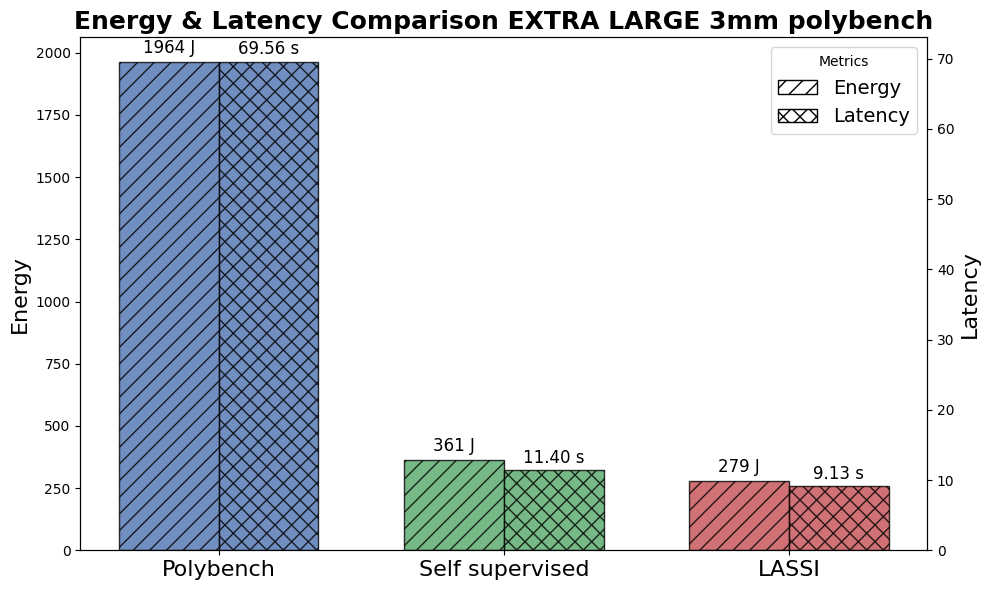

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Inputs
sfs = [source_file_og, source_file_v1, source_file_v3]
labels = ["Polybench", "Self supervised", "LASSI"]

# Values
energies = [sf.get_last_execution_report()[1].energy for sf in sfs]
latencies = [sf.get_last_execution_report()[0].latency for sf in sfs]

x = np.arange(len(labels))
width = 0.35

# Distinct colors for each label
colors = ["#4C72B0", "#55A868", "#C44E52"]   # blue, green, red

# Different hatch patterns for the two metrics
energy_hatch = "//"
latency_hatch = "xx"

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- ENERGY BARS (Left axis) ---
bars1 = ax1.bar(
    x - width/2,
    energies,
    width,
    label="Energy",
    color=colors,
    hatch=energy_hatch,
    edgecolor="black",
    alpha=0.8
)
ax1.set_ylabel("Energy", fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=16)
ax1.set_title("Energy & Latency Comparison EXTRA LARGE 3mm polybench", fontsize=18, fontweight='bold')
ax1.tick_params(axis="y")

# --- LATENCY BARS (Right axis) ---
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width/2,
    latencies,
    width,
    label="Latency",
    color=colors,
    hatch=latency_hatch,
    edgecolor="black",
    alpha=0.8
)
ax2.set_ylabel("Latency", fontsize=16)
ax2.tick_params(axis="y")

# --- Value Annotations ---
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height+ 20,
        f"{height:.0f} J",
        ha="center",
        va="bottom",
        fontsize=12
    )

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f} s",
        ha="center",
        va="bottom",
        fontsize=12
    )

# Legends for the two metrics (hatches)
energy_proxy = plt.Rectangle((0, 0), 1, 1, fc="white", hatch=energy_hatch, edgecolor="black", label="Energy")
latency_proxy = plt.Rectangle((0, 0), 1, 1, fc="white", hatch=latency_hatch, edgecolor="black", label="Latency")

# Legend for label colors
label_patches = [
    plt.Rectangle((0, 0), 1, 1, fc=color, edgecolor="black", label=label)
    for color, label in zip(colors, labels)
]

ax2.legend(handles=[energy_proxy, latency_proxy], title="Metrics", loc="upper right", fontsize=14)

fig.tight_layout()
plt.show()
